# 🚁 Quadrotor Simulation in MuJoCo & MJX: Single-Integrator PID Tutorial

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arunkumar-singh/drone_course_repo/blob/main/tutorials/quadrotor_gym_mujoco_colab.ipynb)

Welcome to this hands-on tutorial on simulating and controlling an autonomous **6-DOF Quadrotor** in Google Colab using **Gymnasium**, **MuJoCo**, and **MJX**.

### Hierarchical Control Architecture
Full quadrotor flight dynamics are complex, underactuated, and non-linear. In practice, robotics engineers use a **two-tier hierarchical control architecture**:

<p align="center">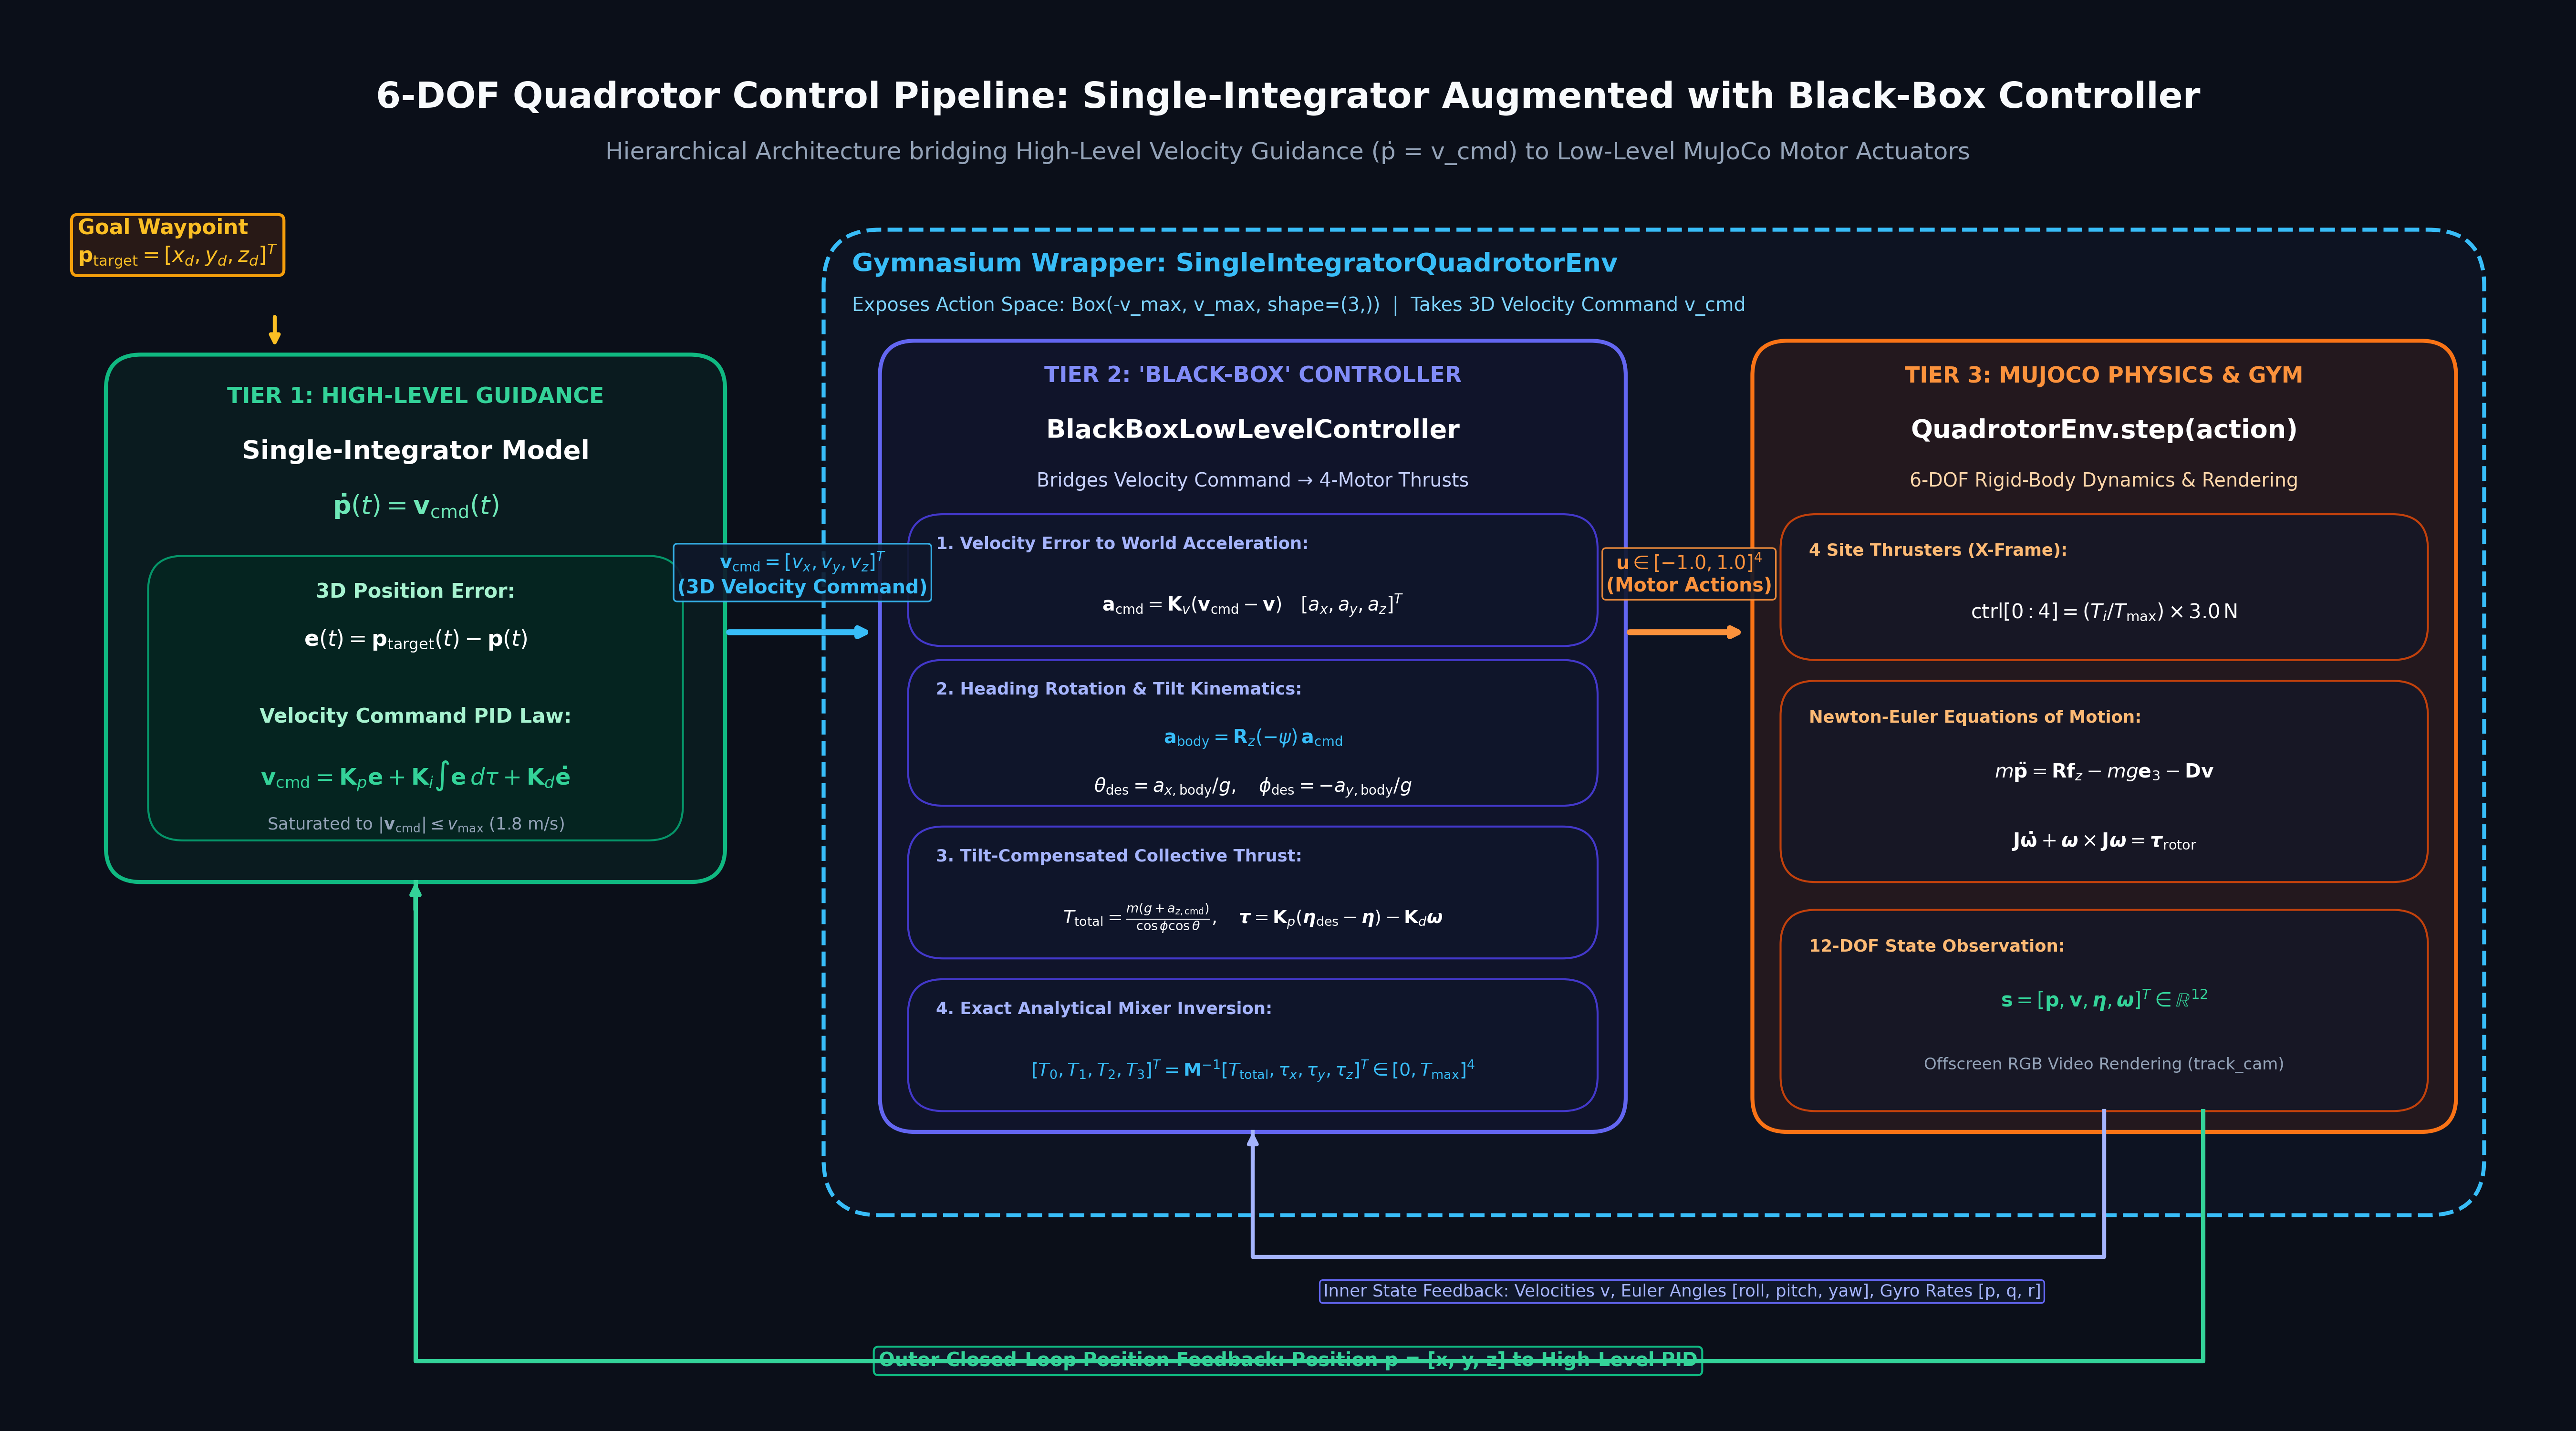</p>

### In This Tutorial, You Will:
1. **Install Dependencies**: Set up `gymnasium`, `mujoco`, and `mediapy` in Colab.
2. **Define Quadrotor MJCF**: Embed the 6-DOF physics model directly in Python.
3. **Build the Gymnasium Environment**: Implement standard `reset()`, `step()`, and `render()`.
4. **Black-Box Lower-Level Bridge**: Implement the black-box controller and expose a `SingleIntegratorQuadrotorEnv` wrapper.
5. **High-Level Single-Integrator PID**: Derive and implement a 3D position PID controller generating velocity commands.
6. **Visual Rollout & In-Colab Video**: Fly through a 3D waypoint mission and view the rendered video directly in Colab.
7. **Bonus: Hardware-Accelerated MJX**: Step 1,024 parallel quadrotors on GPU with JAX.

## 1. Install Dependencies

We install `gymnasium`, `mujoco`, and `mediapy` (for in-notebook video playback).

In [1]:
# Install required packages
!pip install -q gymnasium mujoco mediapy

import os
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import mujoco
import mediapy as media

print(f"MuJoCo Version: {mujoco.__version__}")
print(f"Gymnasium Version: {gym.__version__}")

MuJoCo Version: 3.12.0
Gymnasium Version: 1.3.0


## 2. Define the Quadrotor Model (MJCF XML)

We define the 6-DOF quadrotor in MuJoCo XML format:
- **Freejoint root**: Full 6-DOF rigid-body dynamics (3 translation $+ 3$ rotation)
- **X-Configuration Arms**: 4 thruster site actuators with counter-rotational yaw torque gears
- **Mocap Target Sphere**: Visual golden sphere indicating the current 3D goal waypoint
- **Cameras**: Third-person tracking camera (`track_cam`) and stationary wide observer (`arena_cam`)

In [2]:
QUADROTOR_XML = """
<mujoco model="quadrotor">
  <compiler angle="radian" coordinate="local"/>
  <option gravity="0 0 -9.81" integrator="RK4" timestep="0.01"/>

  <visual>
    <headlight ambient="0.4 0.4 0.4" diffuse="0.8 0.8 0.8" specular="0.1 0.1 0.1"/>
    <rgba haze="0.15 0.25 0.35 1"/>
    <global azimuth="120" elevation="-20" offwidth="1280" offheight="720"/>
  </visual>

  <asset>
    <texture type="skybox" builtin="gradient" rgb1="0.3 0.5 0.7" rgb2="0.0 0.1 0.2" width="512" height="512"/>
    <texture name="grid" type="2d" builtin="checker" width="512" height="512" rgb1="0.25 0.35 0.45" rgb2="0.15 0.2 0.25"/>
    <material name="grid" texture="grid" texrepeat="2 2" texuniform="true" reflectance="0.2"/>
    <material name="chassis" rgba="0.15 0.15 0.15 1.0" specular="0.5" shininess="0.5"/>
    <material name="arm" rgba="0.25 0.25 0.25 1.0"/>
    <material name="front_prop" rgba="0.95 0.15 0.15 0.85" specular="0.4"/>
    <material name="rear_prop" rgba="0.15 0.45 0.95 0.85" specular="0.4"/>
    <material name="target_mat" rgba="1.0 0.8 0.0 0.75" specular="0.9"/>
  </asset>

  <worldbody>
    <light directional="true" diffuse="0.8 0.8 0.8" specular="0.3 0.3 0.3" pos="0 0 6.0" dir="0 0 -1"/>
    <light directional="true" diffuse="0.4 0.4 0.4" specular="0.1 0.1 0.1" pos="4 -4 5.0" dir="-1 1 -1"/>
    <geom name="floor" type="plane" size="12 12 0.1" material="grid" condim="3"/>

    <!-- Target Waypoint Sphere (Mocap Body) -->
    <body name="target" pos="0.0 0.0 1.0" mocap="true">
      <geom name="target_sphere" type="sphere" size="0.08" material="target_mat" contype="0" conaffinity="0" density="0"/>
    </body>

    <!-- Observer Cameras -->
    <camera name="arena_cam" pos="3.8 -3.8 3.0" xyaxes="0.707 0.707 0 -0.408 0.408 0.816" fovy="60"/>

    <!-- 6-DOF Quadrotor Body (mass = 0.500 kg) -->
    <body name="quadrotor" pos="0 0 0.2">
      <freejoint name="root"/>
      <inertial pos="0 0 0" mass="0.500" diaginertia="0.0025 0.0025 0.0045"/>
      <camera name="track_cam" mode="trackcom" pos="0.0 -3.2 1.6" xyaxes="1 0 0 0 0.45 0.89" fovy="60"/>

      <geom name="chassis_geom" type="sphere" size="0.06" material="chassis" density="0"/>
      <geom name="arm1" type="capsule" fromto="0.12 0.12 0 -0.12 -0.12 0" size="0.008" material="arm" density="0"/>
      <geom name="arm2" type="capsule" fromto="-0.12 0.12 0 0.12 -0.12 0" size="0.008" material="arm" density="0"/>

      <!-- Rotor 0: Front-Right (+x, +y) -->
      <geom name="motor0" type="cylinder" pos="0.12 0.12 0.015" size="0.015 0.01" material="chassis" density="0"/>
      <geom name="prop0" type="cylinder" pos="0.12 0.12 0.025" size="0.06 0.002" material="front_prop" contype="0" conaffinity="0" density="0"/>
      <site name="thruster0" pos="0.12 0.12 0.025"/>

      <!-- Rotor 1: Rear-Right (-x, +y) -->
      <geom name="motor1" type="cylinder" pos="-0.12 0.12 0.015" size="0.015 0.01" material="chassis" density="0"/>
      <geom name="prop1" type="cylinder" pos="-0.12 0.12 0.025" size="0.06 0.002" material="rear_prop" contype="0" conaffinity="0" density="0"/>
      <site name="thruster1" pos="-0.12 0.12 0.025"/>

      <!-- Rotor 2: Rear-Left (-x, -y) -->
      <geom name="motor2" type="cylinder" pos="-0.12 -0.12 0.015" size="0.015 0.01" material="chassis" density="0"/>
      <geom name="prop2" type="cylinder" pos="-0.12 -0.12 0.025" size="0.06 0.002" material="rear_prop" contype="0" conaffinity="0" density="0"/>
      <site name="thruster2" pos="-0.12 -0.12 0.025"/>

      <!-- Rotor 3: Front-Left (+x, -y) -->
      <geom name="motor3" type="cylinder" pos="0.12 -0.12 0.015" size="0.015 0.01" material="chassis" density="0"/>
      <geom name="prop3" type="cylinder" pos="0.12 -0.12 0.025" size="0.06 0.002" material="front_prop" contype="0" conaffinity="0" density="0"/>
      <site name="thruster3" pos="0.12 -0.12 0.025"/>
    </body>
  </worldbody>

  <!-- Actuators: 4 Site Thrusters -->
  <actuator>
    <general name="thrust0" site="thruster0" gear="0 0 1 0 0  0.015" ctrlrange="0 3.0" ctrllimited="true"/>
    <general name="thrust1" site="thruster1" gear="0 0 1 0 0 -0.015" ctrlrange="0 3.0" ctrllimited="true"/>
    <general name="thrust2" site="thruster2" gear="0 0 1 0 0  0.015" ctrlrange="0 3.0" ctrllimited="true"/>
    <general name="thrust3" site="thruster3" gear="0 0 1 0 0 -0.015" ctrlrange="0 3.0" ctrllimited="true"/>
  </actuator>
</mujoco>
"""
print("Quadrotor MJCF definition loaded!")

Quadrotor MJCF definition loaded!


## 3. Base Gymnasium Environment (`QuadrotorEnv`)

The base environment handles the raw MuJoCo physics:
- **Action Space**: 4 individual motor thrust inputs in $[-1.0, 1.0]$
- **Observation Space**: 12-dim state vector ($[x,y,z]$, $[\dot{x},\dot{y},\dot{z}]$, Euler angles $[\phi,\theta,\psi]$, and body rates $[p,q,r]$)
- **Offscreen Rendering**: Built-in `mujoco.Renderer` extracting RGB pixel arrays for video recording

In [3]:
class QuadrotorEnv(gym.Env):
    """
    Base 6-DOF Quadrotor Gymnasium Environment.
    Low-level interface expects 4-motor thrust action commands in [-1.0, 1.0].
    """
    metadata = {"render_modes": ["rgb_array"], "render_fps": 30}

    def __init__(
        self,
        xml_string=QUADROTOR_XML,
        target_pos=(0.0, 0.0, 1.0),
        dt=0.01,
        frame_skip=2,
        max_steps=350,
        camera_name="track_cam",
        render_width=720,
        render_height=540,
    ):
        super().__init__()

        self.model = mujoco.MjModel.from_xml_string(xml_string)
        self.model.opt.timestep = dt
        self.data = mujoco.MjData(self.model)

        self.dt = dt
        self.frame_skip = frame_skip
        self.max_steps = max_steps
        self.camera_name = camera_name
        self.target_pos = np.array(target_pos, dtype=np.float32)

        # Quadrotor Mass & Thrust Parameters
        self.body_id = mujoco.mj_name2id(self.model, mujoco.mjtObj.mjOBJ_BODY, "quadrotor")
        self.mass = float(self.model.body_mass[self.body_id])
        self.g = 9.81
        self.hover_thrust = (self.mass * self.g) / 4.0
        self.max_motor_thrust = float(self.model.actuator_ctrlrange[0, 1])

        # Low-level Action Space: 4 normalized motor commands
        self.action_space = spaces.Box(
            low=-1.0, high=1.0, shape=(self.model.nu,), dtype=np.float32
        )

        # 12-dimensional State Observation Space
        high_obs = np.array([
            10.0, 10.0, 10.0,     # pos (m)
            20.0, 20.0, 20.0,     # vel (m/s)
            np.pi, np.pi, np.pi,  # roll, pitch, yaw (rad)
            20.0, 20.0, 20.0,     # p, q, r (rad/s)
        ], dtype=np.float32)
        self.observation_space = spaces.Box(low=-high_obs, high=high_obs, dtype=np.float32)

        self.current_step = 0
        self.renderer = mujoco.Renderer(self.model, height=render_height, width=render_width)

    def set_target_pos(self, target_pos):
        """Update target waypoint position in physics & visualizer."""
        self.target_pos = np.array(target_pos, dtype=np.float32)
        self.data.mocap_pos[0] = self.target_pos

    def _quat_to_euler(self, q):
        w, x, y, z = q
        sinr_cosp = 2.0 * (w * x + y * z)
        cosr_cosp = 1.0 - 2.0 * (x * x + y * y)
        roll = np.arctan2(sinr_cosp, cosr_cosp)

        sinp = np.clip(2.0 * (w * y - z * x), -1.0, 1.0)
        pitch = np.arcsin(sinp)

        siny_cosp = 2.0 * (w * z + x * y)
        cosy_cosp = 1.0 - 2.0 * (y * y + z * z)
        yaw = np.arctan2(siny_cosp, cosy_cosp)
        return np.array([roll, pitch, yaw], dtype=np.float32)

    def _get_obs(self):
        pos = self.data.qpos[0:3].copy()
        rpy = self._quat_to_euler(self.data.qpos[3:7])
        vel = self.data.qvel[0:3].copy()
        omega = self.data.qvel[3:6].copy()
        return np.concatenate([pos, vel, rpy, omega]).astype(np.float32)

    def _get_info(self):
        pos = self.data.qpos[0:3]
        dist = np.linalg.norm(pos - self.target_pos)
        return {"step": self.current_step, "dist_to_target": float(dist), "altitude": float(pos[2])}

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        mujoco.mj_resetData(self.model, self.data)
        self.data.mocap_pos[0] = self.target_pos

        self.data.qpos[0:3] = [0.0, 0.0, 0.2]
        self.data.qpos[3:7] = [1.0, 0.0, 0.0, 0.0]
        self.data.qvel[:] = 0.0
        mujoco.mj_forward(self.model, self.data)

        self.current_step = 0
        return self._get_obs(), self._get_info()

    def step(self, action):
        self.current_step += 1

        action = np.clip(action, -1.0, 1.0)
        thrusts = (action + 1.0) * 0.5 * self.max_motor_thrust
        self.data.ctrl[:] = thrusts

        for _ in range(self.frame_skip):
            mujoco.mj_step(self.model, self.data)

        obs = self._get_obs()
        pos, vel, rpy = obs[0:3], obs[3:6], obs[6:9]

        pos_error = np.linalg.norm(pos - self.target_pos)
        reward = float(1.0 / (1.0 + pos_error) - 0.1 * np.linalg.norm(vel) - 0.2 * np.linalg.norm(rpy[0:2]))

        crashed = pos[2] < 0.05 or abs(rpy[0]) > np.deg2rad(70) or abs(rpy[1]) > np.deg2rad(70)
        out_of_bounds = np.any(np.abs(pos[0:2]) > 6.0) or pos[2] > 6.0
        terminated = bool(crashed or out_of_bounds)
        truncated = bool(self.current_step >= self.max_steps)

        return obs, reward, terminated, truncated, self._get_info()

    def render(self, camera_name=None):
        cam = camera_name if camera_name is not None else self.camera_name
        self.renderer.update_scene(self.data, camera=cam)
        return self.renderer.render()

    def close(self):
        if self.renderer is not None:
            self.renderer.close()
            self.renderer = None

print("Base QuadrotorEnv created!")

Base QuadrotorEnv created!


## 4. The Single-Integrator Abstraction & "Black-Box" Lower-Level Bridge

### Hierarchical Control Pipeline Architecture
The diagram below illustrates the complete 3-tier control flow with dual feedback loops:

<p align="center">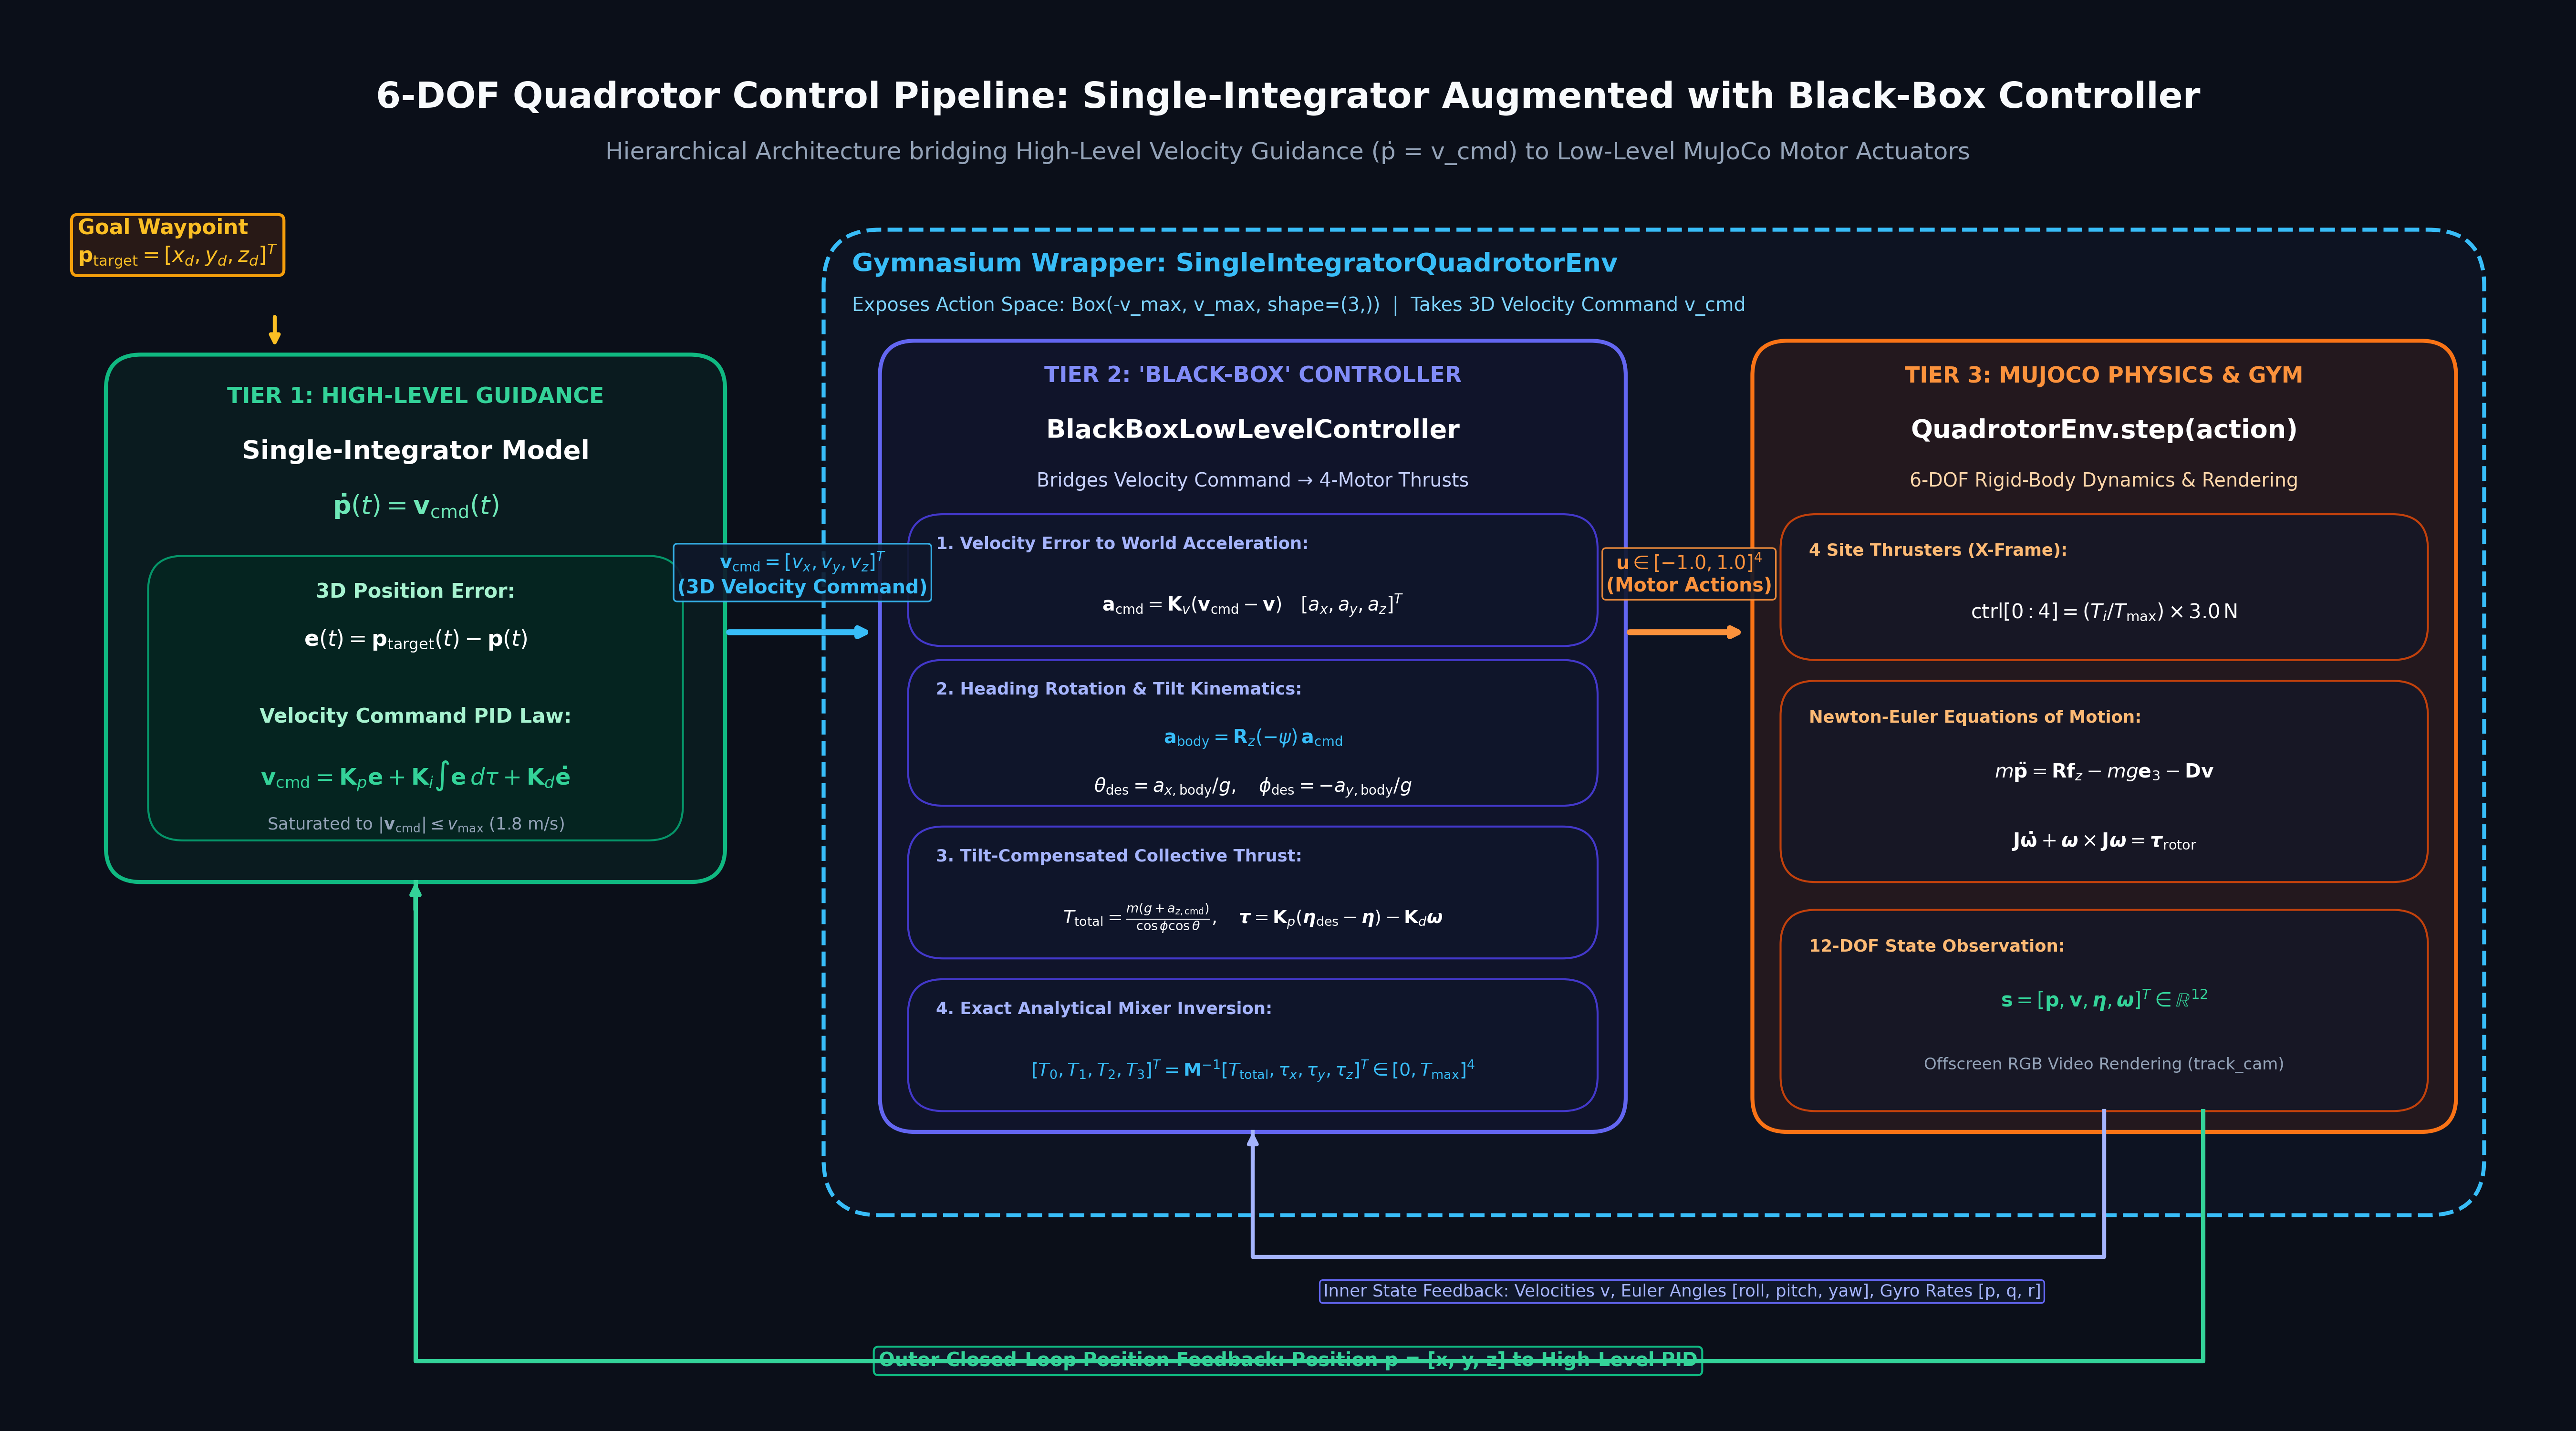</p>


### The Single-Integrator Dynamics Model
To simplify planning, guidance, and high-level control, we abstract the 6-DOF quadrotor as a **single integrator system**:
$$\dot{\mathbf{p}}(t) = \mathbf{v}_{\text{cmd}}(t)$$
where $\mathbf{p} = [x, y, z]^T \in \mathbb{R}^3$ is position, and the control input chosen by our high-level controller is a **3D velocity command**:
$$\mathbf{u}_{\text{high}} = \mathbf{v}_{\text{cmd}} = [v_{x,\text{cmd}}, v_{y,\text{cmd}}, v_{z,\text{cmd}}]^T$$

### The "Black-Box" Lower-Level Controller (`BlackBoxLowLevelController`)
Sitting directly between the high-level velocity commands and MuJoCo's 4 motor actuators is the **black-box controller**. It automatically handles all complex aerodynamics and flight dynamics:
1. **Velocity Tracking**: Computes desired body accelerations from velocity errors: $\mathbf{a}_{\text{cmd}} = K_v (\mathbf{v}_{\text{cmd}} - \mathbf{v})$
2. **Heading & Tilt Kinematics**: Maps horizontal accelerations to roll ($\phi_{\text{des}}$) and pitch ($\theta_{\text{des}}$) angles in the quadrotor's body heading frame
3. **Tilt Compensation**: Scales collective thrust by $\frac{1}{\cos\phi \cos\theta}$ so the drone does not drop altitude when banking
4. **Motor Allocation Mixer Inversion**: Inverts the physical mixer matrix to produce individual motor commands $[T_0, T_1, T_2, T_3]$

We wrap the base environment using `SingleIntegratorQuadrotorEnv(gym.Wrapper)`, which **exposes the 3D velocity command directly as the Gym action space**!

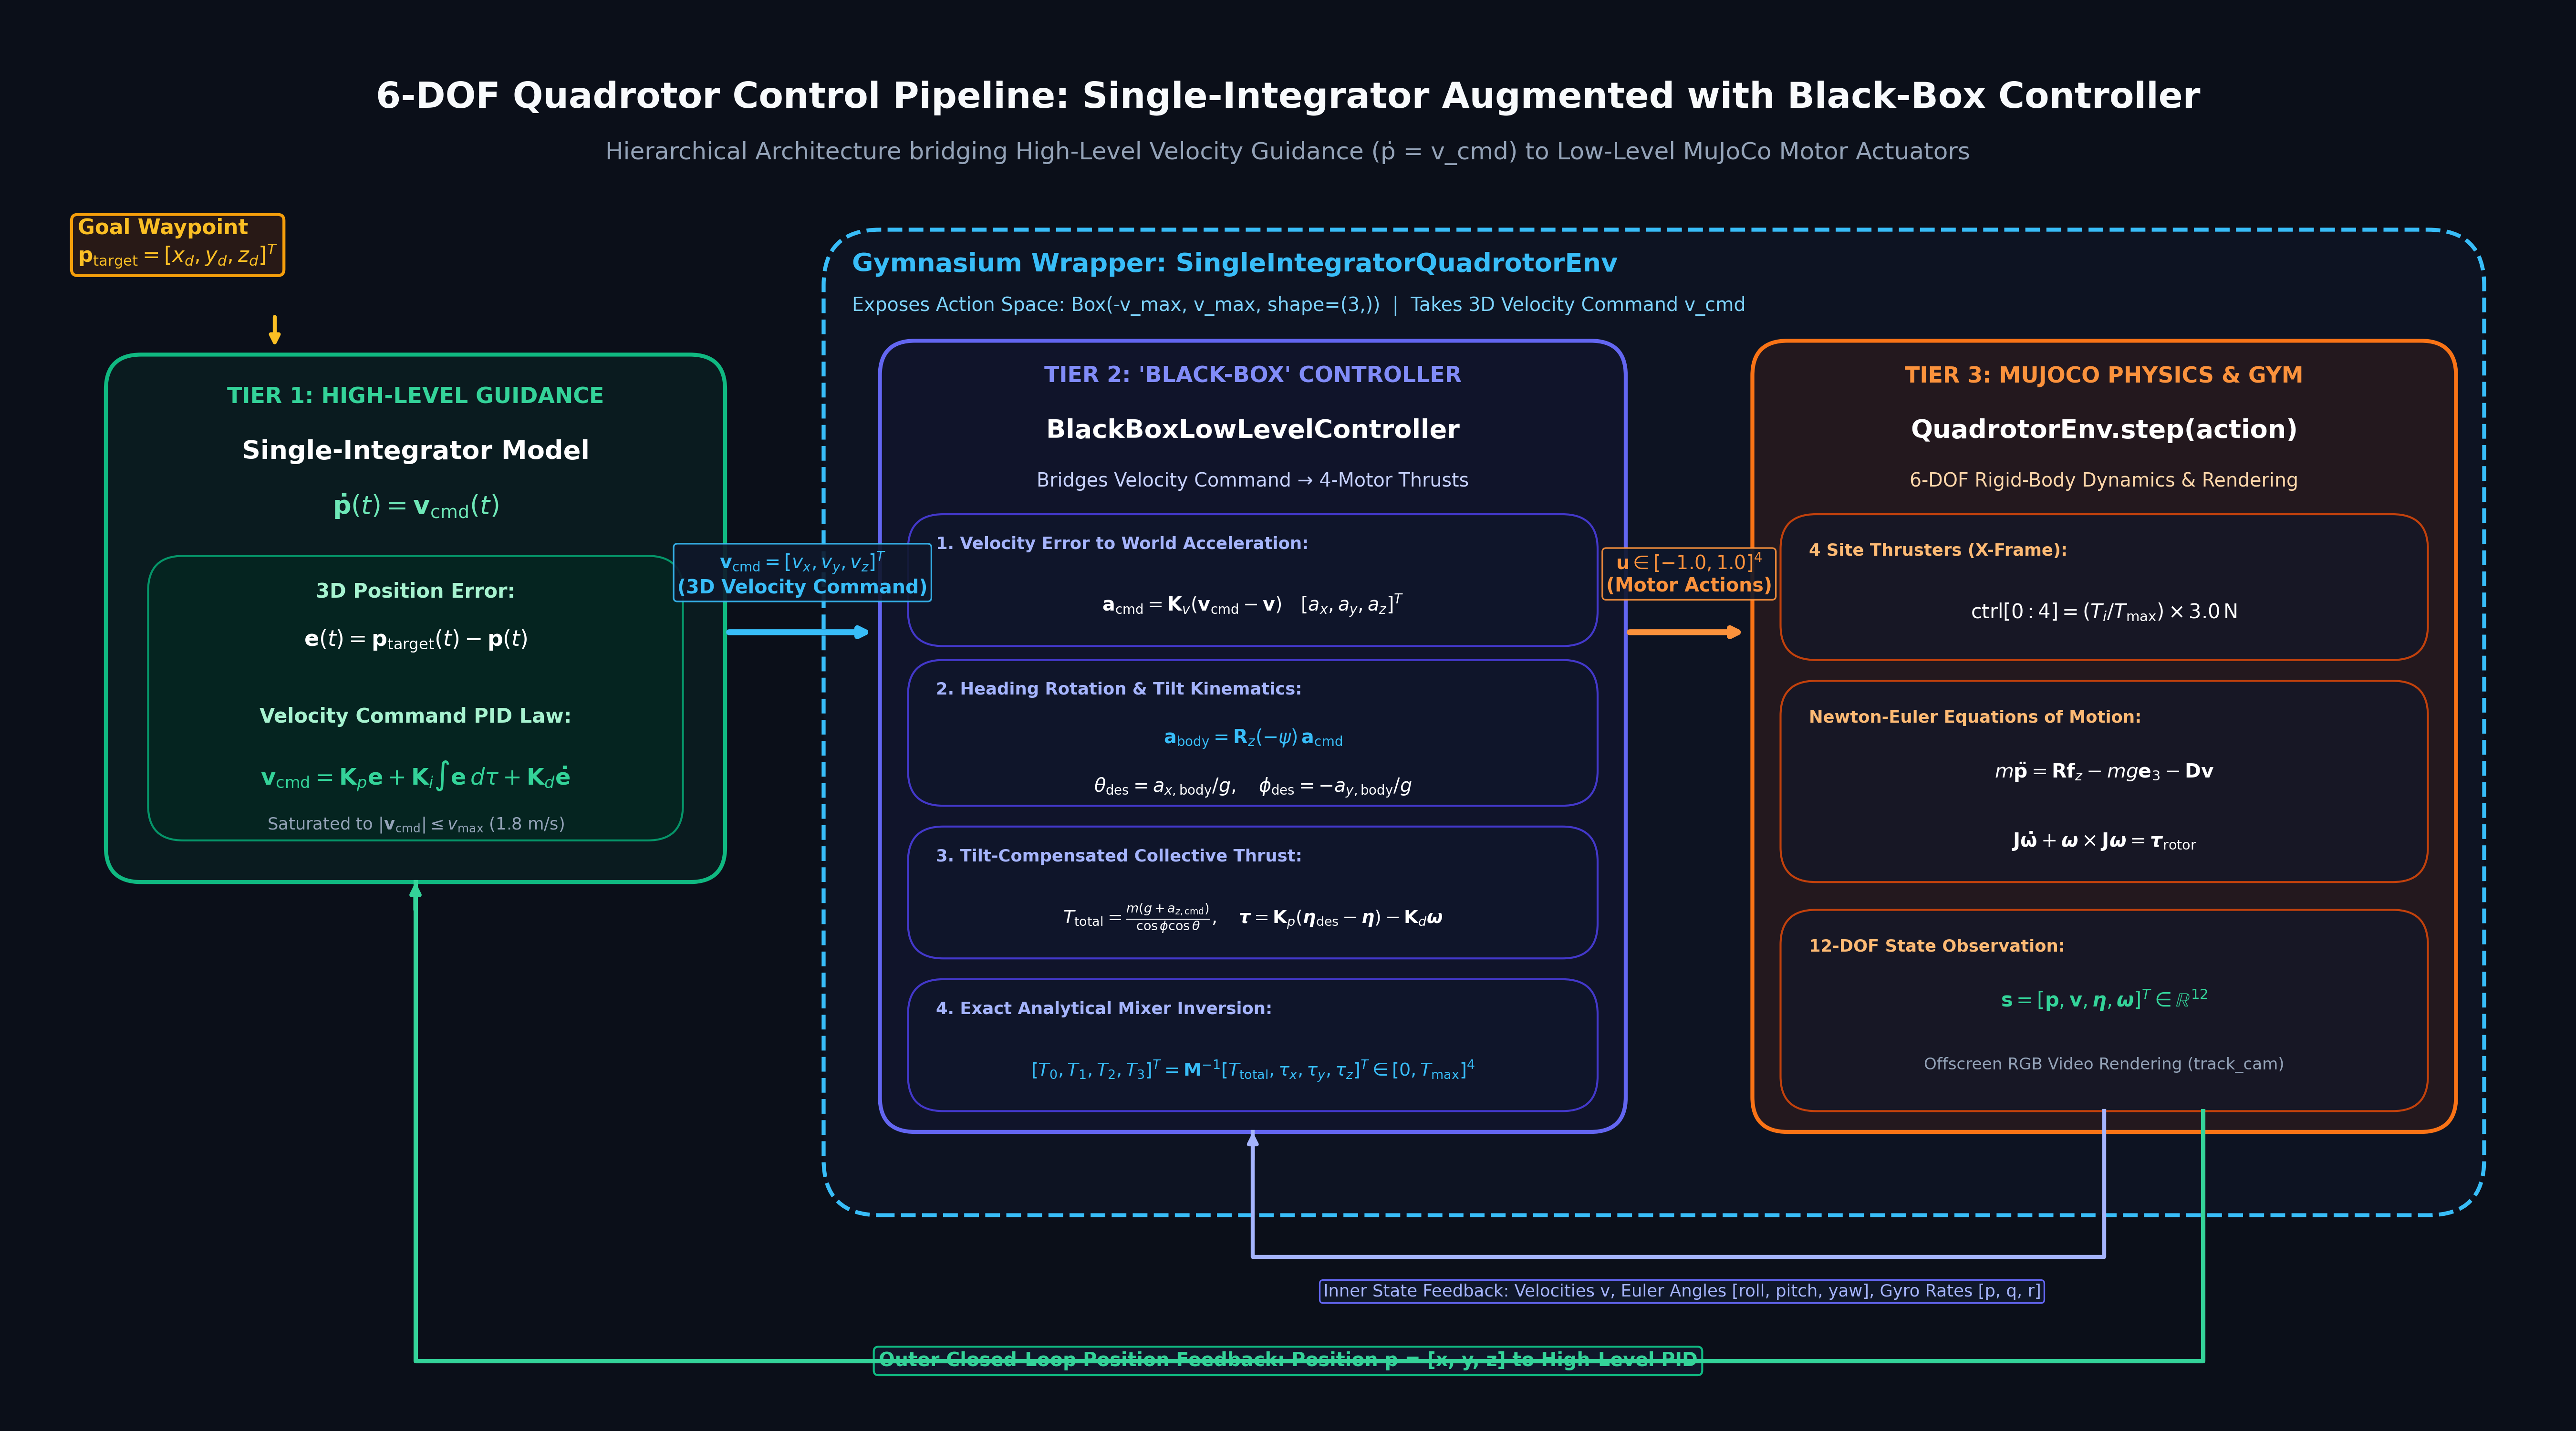

In [4]:
# Display Pipeline Architecture Diagram
from IPython.display import Image, display
import os

img_candidates = [
    "single_integrator_pipeline.png",
    "tutorials/single_integrator_pipeline.png",
    "/home/aks1/drone_course_repo/tutorials/single_integrator_pipeline.png",
]
img_found = next((p for p in img_candidates if os.path.exists(p)), None)

if img_found:
    display(Image(img_found, width=950))
else:
    display(Image("https://raw.githubusercontent.com/arunkumar-singh/drone_course_repo/main/tutorials/single_integrator_pipeline.png", width=950))

In [5]:
class BlackBoxLowLevelController:
    """
    Black-Box Lower-Level Flight Controller.
    Bridges high-level 3D velocity commands v_cmd to MuJoCo 4-rotor thrust actuators.
    """
    def __init__(self, mass=0.500, g=9.81, max_thrust=3.0, d=0.12, c_tau=0.015):
        self.mass = mass
        self.g = g
        self.max_thrust = max_thrust
        self.d = d
        self.c_tau = c_tau

    def compute_motor_action(self, v_cmd, obs):
        """
        Takes high-level velocity command v_cmd = [vx, vy, vz] and current state obs.
        Returns normalized 4-motor action in [-1.0, 1.0] for MuJoCo.
        """
        pos, vel = obs[0:3], obs[3:6]
        roll, pitch, yaw = obs[6:9]
        p, q, r = obs[9:12]

        # 1. Desired accelerations from velocity tracking
        ax_world = 3.2 * (v_cmd[0] - vel[0])
        ay_world = 3.2 * (v_cmd[1] - vel[1])
        az_cmd   = 6.0 * (v_cmd[2] - vel[2])

        # 2. Heading rotation into quadrotor yaw frame
        cy, sy = np.cos(yaw), np.sin(yaw)
        ax_body =  cy * ax_world + sy * ay_world
        ay_body = -sy * ax_world + cy * ay_world

        # Tilt angle kinematics
        pitch_des = np.clip(ax_body / self.g, -0.25, 0.25)
        roll_des  = np.clip(-ay_body / self.g, -0.25, 0.25)

        # 3. Attitude stabilization torques
        tau_x = 0.075 * (roll_des - roll) - 0.015 * p
        tau_y = 0.075 * (pitch_des - pitch) - 0.015 * q
        tau_z = 0.020 * (0.0 - yaw) - 0.005 * r

        # 4. Collective thrust with tilt compensation
        tilt_comp = np.clip(np.cos(roll) * np.cos(pitch), 0.65, 1.0)
        total_thrust = np.clip(self.mass * (self.g + az_cmd) / tilt_comp, 0.1 * self.mass * self.g, 1.9 * self.mass * self.g)

        # 5. Exact analytical inverse allocation mixer
        inv_4d = 1.0 / (4.0 * self.d)
        inv_4c = 1.0 / (4.0 * self.c_tau)
        base = total_thrust / 4.0

        t0 = base + inv_4d * tau_x - inv_4d * tau_y + inv_4c * tau_z
        t1 = base + inv_4d * tau_x + inv_4d * tau_y - inv_4c * tau_z
        t2 = base - inv_4d * tau_x + inv_4d * tau_y + inv_4c * tau_z
        t3 = base - inv_4d * tau_x - inv_4d * tau_y - inv_4c * tau_z

        thrusts = np.clip([t0, t1, t2, t3], 0.0, self.max_thrust)
        return ((thrusts / (0.5 * self.max_thrust)) - 1.0).astype(np.float32)


class SingleIntegratorQuadrotorEnv(gym.Wrapper):
    """
    Gymnasium Wrapper exposing a Single-Integrator Interface: ṗ = v_cmd.
    Action Space: 3D Velocity Command [vx, vy, vz] in m/s.
    """
    def __init__(self, env, v_max=2.0):
        super().__init__(env)
        self.v_max = v_max
        # Action space is now a 3D velocity command in m/s!
        self.action_space = spaces.Box(low=-v_max, high=v_max, shape=(3,), dtype=np.float32)
        self.black_box = BlackBoxLowLevelController(
            mass=env.mass, max_thrust=env.max_motor_thrust
        )

    def step(self, v_cmd):
        # 1. Retrieve current observation
        current_obs = self.env._get_obs()
        v_cmd_clipped = np.clip(v_cmd, -self.v_max, self.v_max)

        # 2. Black-box controller generates low-level 4-motor commands
        motor_action = self.black_box.compute_motor_action(v_cmd_clipped, current_obs)

        # 3. Step raw MuJoCo environment
        return self.env.step(motor_action)

    def set_target_pos(self, target_pos):
        """Forward target waypoint updates to inner environment."""
        self.env.set_target_pos(target_pos)

print("BlackBoxLowLevelController and SingleIntegratorQuadrotorEnv ready!")

BlackBoxLowLevelController and SingleIntegratorQuadrotorEnv ready!


## 5. High-Level Single-Integrator PID Controller

Now we implement the **High-Level Position PID Controller**.

### Mathematical Derivation
For a single-integrator system $\dot{\mathbf{p}} = \mathbf{v}_{\text{cmd}}$, let position error be:
$$\mathbf{e}(t) = \mathbf{p}_{\text{target}}(t) - \mathbf{p}(t)$$

The high-level PID control law calculates the 3D velocity command as:
$$\mathbf{v}_{\text{cmd}}(t) = K_p \mathbf{e}(t) + K_i \int_0^t \mathbf{e}(\tau)\,d\tau + K_d \frac{d\mathbf{e}(t)}{dt}$$

### Closed-Loop Dynamics
Substituting $\dot{\mathbf{p}} = \mathbf{v}_{\text{cmd}}$ into the error dynamics:
$$\dot{\mathbf{e}} = \dot{\mathbf{p}}_{\text{target}} - \mathbf{v}_{\text{cmd}}$$
For stationary waypoints ($\dot{\mathbf{p}}_{\text{target}} = 0$):
$$\dot{\mathbf{e}} + K_p \mathbf{e} + K_i \int \mathbf{e}\,d\tau + K_d \dot{\mathbf{e}} = 0$$
- **Proportional Gain ($K_p$)**: Acts as a virtual spring pulling the drone toward the target waypoint with convergence rate $\tau = 1/K_p$.
- **Integral Gain ($K_i$)**: Eliminates steady-state positioning error.
- **Derivative Gain ($K_d$)**: Acts as damping to prevent velocity overshoot.

In [6]:
class HighLevelPositionPID:
    """
    High-Level 3D Position PID Controller assuming Single-Integrator Dynamics (ṗ = v_cmd).
    Computes velocity commands [vx, vy, vz] to navigate to target waypoints.
    """
    def __init__(self, kp=2.2, ki=0.3, kd=0.4, v_max=1.8):
        self.kp = kp
        self.ki = ki
        self.kd = kd
        self.v_max = v_max
        self.integral = np.zeros(3, dtype=np.float32)
        self.prev_error = np.zeros(3, dtype=np.float32)

    def reset(self):
        self.integral = np.zeros(3, dtype=np.float32)
        self.prev_error = np.zeros(3, dtype=np.float32)

    def compute(self, current_pos, target_pos, dt=0.02):
        """
        Computes 3D velocity command v_cmd from current position and target waypoint.
        """
        error = np.array(target_pos, dtype=np.float32) - np.array(current_pos, dtype=np.float32)

        # Conditional anti-windup integration
        if np.linalg.norm(error) < 0.6:
            self.integral = np.clip(self.integral + error * dt, -0.5, 0.5)

        # Derivative of error
        derivative = (error - self.prev_error) / dt
        self.prev_error = error.copy()

        # PID Velocity Command Law
        v_cmd = self.kp * error + self.ki * self.integral + self.kd * derivative

        # Velocity magnitude saturation limit
        speed = np.linalg.norm(v_cmd)
        if speed > self.v_max:
            v_cmd = v_cmd * (self.v_max / speed)

        return v_cmd.astype(np.float32)

print("HighLevelPositionPID controller implemented!")

HighLevelPositionPID controller implemented!


## 6. End-to-End Simulation Rollout & In-Colab Video Playback

Notice how clean and intuitive the interaction loop becomes:
```python
# 1. High-level PID computes 3D velocity command
v_cmd = pid.compute(pos, current_target, dt=0.02)

# 2. Step the Gymnasium environment directly with the velocity command!
obs, reward, terminated, truncated, info = env.step(v_cmd)
```

Let's execute a 3D multi-waypoint flight patrol and render the video directly inside Colab!

In [7]:
# 1. Define 3D Multi-Waypoint Route
waypoints = [
    np.array([ 0.0,  0.0, 1.2]),  # Takeoff / Center
    np.array([ 1.2,  1.2, 1.6]),  # Waypoint 1 (Front-Right)
    np.array([-1.2,  1.2, 1.8]),  # Waypoint 2 (Rear-Right)
    np.array([-1.2, -1.2, 1.2]),  # Waypoint 3 (Rear-Left)
    np.array([ 1.2, -1.2, 1.5]),  # Waypoint 4 (Front-Left)
    np.array([ 0.0,  0.0, 1.2]),  # Home Hover
]

# 2. Instantiate Base Environment and wrap with Single-Integrator Interface
base_env = QuadrotorEnv(target_pos=waypoints[0], camera_name="track_cam")
env = SingleIntegratorQuadrotorEnv(base_env, v_max=1.8)

print(f"Wrapped Action Space:      {env.action_space} (3D Velocity Commands [vx, vy, vz])")
print(f"Wrapped Observation Space: {env.observation_space}")

# 3. Instantiate High-Level PID
pid = HighLevelPositionPID(kp=2.2, ki=0.3, kd=0.4, v_max=1.8)

obs, info = env.reset(seed=42)
frames = [env.render()]

wp_idx = 0
current_target = waypoints[wp_idx]
env.set_target_pos(current_target)
dwell_steps = 0

print("\n--- Executing Autonomous Multi-Waypoint Flight ---")
for step in range(1, 350):
    pos = obs[0:3]
    dist = np.linalg.norm(pos - current_target)

    # Waypoint Transition Logic: converge < 18cm and hold for 10 steps
    if dist < 0.18:
        dwell_steps += 1
        if dwell_steps > 10 and wp_idx < len(waypoints) - 1:
            wp_idx += 1
            current_target = waypoints[wp_idx]
            env.set_target_pos(current_target)
            dwell_steps = 0
            print(f"--> [Step {step:03d}] Reached Waypoint! New Target WP{wp_idx}: {current_target}")
    else:
        dwell_steps = 0

    # 1. High-Level PID computes velocity command
    v_cmd = pid.compute(current_pos=pos, target_pos=current_target, dt=0.02)

    # 2. Step environment directly with v_cmd!
    # Black-box controller translates v_cmd -> 4-motor thrusts -> MuJoCo
    obs, reward, terminated, truncated, info = env.step(v_cmd)

    # 3. Capture camera frame from MuJoCo Visualizer
    frames.append(env.render())

    if step % 50 == 0:
        print(f"Step {step:03d} | Pos: [{pos[0]:5.2f}, {pos[1]:5.2f}, {pos[2]:5.2f}] | v_cmd: [{v_cmd[0]:5.2f}, {v_cmd[1]:5.2f}, {v_cmd[2]:5.2f}] | Error: {dist*100:5.1f} cm")

    if terminated or truncated:
        break

env.close()
print(f"\nFlight Tour Finished! Total frames captured: {len(frames)}")

# 4. Display Simulation Video inline inside Colab
print("Displaying Simulation Video:")
try:
    media.show_video(frames, fps=30)
except Exception as e:
    print(f"Video preview note: {e} (In Google Colab, media.show_video displays the interactive video player inline!)")

Wrapped Action Space:      Box(-1.8, 1.8, (3,), float32) (3D Velocity Commands [vx, vy, vz])
Wrapped Observation Space: Box([-10.        -10.        -10.        -20.        -20.        -20.
  -3.1415927  -3.1415927  -3.1415927 -20.        -20.        -20.       ], [10.        10.        10.        20.        20.        20.
  3.1415927  3.1415927  3.1415927 20.        20.        20.       ], (12,), float32)

--- Executing Autonomous Multi-Waypoint Flight ---
Step 050 | Pos: [ 0.00,  0.00,  1.02] | v_cmd: [ 0.00,  0.00,  0.30] | Error:  18.4 cm
--> [Step 061] Reached Waypoint! New Target WP1: [1.2 1.2 1.6]
Step 100 | Pos: [ 0.39,  0.39,  1.38] | v_cmd: [ 1.23,  1.24,  0.39] | Error: 116.1 cm


--> [Step 135] Reached Waypoint! New Target WP2: [-1.2  1.2  1.8]
Step 150 | Pos: [ 1.24,  1.22,  1.61] | v_cmd: [-1.79,  0.03,  0.15] | Error: 244.7 cm
Step 200 | Pos: [-0.24,  1.25,  1.76] | v_cmd: [-1.33, -0.17,  0.12] | Error:  96.5 cm
--> [Step 236] Reached Waypoint! New Target WP3: [-1.2 -1.2  1.2]
Step 250 | Pos: [-1.19,  1.15,  1.76] | v_cmd: [-0.03, -1.77, -0.35] | Error: 242.0 cm


Step 300 | Pos: [-1.22,  0.10,  1.46] | v_cmd: [ 0.07, -1.77, -0.32] | Error: 132.1 cm
--> [Step 348] Reached Waypoint! New Target WP4: [ 1.2 -1.2  1.5]

Flight Tour Finished! Total frames captured: 350
Displaying Simulation Video:


This browser does not support the video tag.


## 7. Bonus: Parallel Simulation on GPU with MuJoCo MJX

**MuJoCo MJX** provides hardware-accelerated (GPU/TPU) parallel physics in JAX.
Instead of running a single environment sequentially on the CPU, MJX allows you to step **thousands of quadrotors in parallel** using `jax.vmap`.

In [8]:
from mujoco import mjx
import jax
import jax.numpy as jnp

# 1. Convert MuJoCo Model to MJX
mj_model = mujoco.MjModel.from_xml_string(QUADROTOR_XML)
mjx_model = mjx.put_model(mj_model)
mjx_data = mjx.put_data(mj_model, mujoco.MjData(mj_model))

print(f"JAX Default Backend: {jax.default_backend()}")
print(f"Available Devices:   {jax.devices()}")

# 2. Define JIT-compiled single-environment step function
@jax.jit
def mjx_step_fn(m, d, ctrl):
    d = d.replace(ctrl=ctrl)
    return mjx.step(m, d)

# 3. Vectorize across N parallel environments with jax.vmap
N_ENVS = 1024
batched_step = jax.jit(jax.vmap(mjx_step_fn, in_axes=(None, 0, 0)))

# Initialize 1,024 parallel states
batch_data = jax.vmap(lambda _: mjx_data)(jnp.arange(N_ENVS))

# Generate random motor inputs for all 1,024 drones
key = jax.random.PRNGKey(0)
batch_ctrl = jax.random.uniform(key, shape=(N_ENVS, mj_model.nu), minval=0.0, maxval=3.0)

# Execute parallel step
batch_data_next = batched_step(mjx_model, batch_data, batch_ctrl)

print(f"Stepped {N_ENVS} parallel quadrotor environments in one GPU pass!")
print(f"Batch qpos tensor shape: {batch_data_next.qpos.shape}")

JAX Default Backend: gpu
Available Devices:   [CudaDevice(id=0)]


Stepped 1024 parallel quadrotor environments in one GPU pass!
Batch qpos tensor shape: (1024, 7)


## Summary

In this tutorial, you learned:
1. How to define and load a 6-DOF quadrotor model in **MuJoCo**
2. The **single-integrator abstraction** ($\dot{\mathbf{p}} = \mathbf{v}_{\text{cmd}}$) for quadrotor navigation
3. How to build a **black-box lower-level controller** that bridges high-level velocity commands with raw 4-motor actuators
4. How to implement and tune a **High-Level Position PID Controller** interacting with Gymnasium
5. How to render and display HD simulation videos inline using **MediaPy**
6. How to scale to massive parallel simulation on GPU using **MuJoCo MJX**